# Importação das bibliotecas necessárias para o processamento de dados, visualização e modelagem.

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

import os
import zipfile

# Upload, Descompactação e Leitura de Dados

In [3]:
from google.colab import files


In [4]:
uploaded = files.upload()

Saving archive.zip to archive.zip


In [9]:
import os
print(os.listdir())


['.config', 'archive.zip', 'sample_data']


In [11]:
file_name = 'archive.zip'

In [12]:
import zipfile

In [13]:
if file_name in uploaded:
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("/content/ocorrencias_aviacao")
else:
    print(f'O arquivo {file_name} não foi carregado corretamente.')

In [ ]:
df = pd.read_csv('/content/ocorrencias_aviacao/ocoraero.csv')

In [15]:
df.head()

,codigo_ocorrencia,ocorrencia_classificacao,ocorrencia_tipo,ocorrencia_tipo_categoria,ocorrencia_tipo_icao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_pais,...,ocorrencia_horario,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista,ocorrencia_dia_extracao
0,201305055424986,ACIDENTE,FALHA DO MOTOR EM VOO,FALHA OU MAU FUNCIONAMENTO DO MOTOR,SCF-PP,-9.9085,-63.0333,ARIQUEMES,RO,BRASIL,...,11:00:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
1,201605160250139,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,CTOL,-11.2644,-61.2589,CACOAL,RO,BRASIL,...,19:19:00,SIM,ATIVA,IG-084/CENIPA/2016,NÃO,NaN,0,1,NÃO,2018-08-28
2,201805021421302,INCIDENTE,AERÓDROMO,AERÓDROMO,ADRM,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,22:40:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
3,201311259977425,INCIDENTE GRAVE,POUSO SEM TREM,CONTATO ANORMAL COM A PISTA,ARC,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,12:32:00,NaN,FINALIZADA,IG-209/CENIPA/2013,SIM,2014-04-07,0,1,NÃO,2018-08-28
4,201103187273112,INCIDENTE,OUTROS,OUTROS,OTHR,-13.1950,-60.8184,CEREJEIRAS,RO,BRASIL,...,13:30:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   codigo_ocorrencia               5208 non-null   int64  
 1   ocorrencia_classificacao        5208 non-null   object 
 2   ocorrencia_tipo                 5208 non-null   object 
 3   ocorrencia_tipo_categoria       5208 non-null   object 
 4   ocorrencia_tipo_icao            5208 non-null   object 
 5   ocorrencia_latitude             5208 non-null   float64
 6   ocorrencia_longitude            5208 non-null   float64
 7   ocorrencia_cidade               5208 non-null   object 
 8   ocorrencia_uf                   5208 non-null   object 
 9   ocorrencia_pais                 5208 non-null   object 
 10  ocorrencia_aerodromo            5208 non-null   object 
 11  ocorrencia_dia                  5208 non-null   object 
 12  ocorrencia_horario              52

In [ ]:
print("Verificando valores nulos no DataFrame:")
print(df.isnull().sum())

# Análise Exploratória e Criação da Coluna "Fator Predominante"

In [24]:
print("Valores únicos em 'ocorrencia_tipo_categoria':")
print(df['ocorrencia_tipo_categoria'].unique())

Valores únicos em 'ocorrencia_tipo_categoria':
['FALHA OU MAU FUNCIONAMENTO DO MOTOR'
 'COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO' 'AERÓDROMO'
 'CONTATO ANORMAL COM A PISTA' 'OUTROS' 'PERDA DE CONTROLE NO SOLO'
 'EXCURSÃO DE PISTA' 'PERDA DE SEPARAÇÃO / COLISÃO EM VOO'
 'PERDA DE CONTROLE EM VOO'
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE' 'INDETERMINADO'
 'VOO CONTROLADO CONTRA O TERRENO' 'INCURSÃO EM PISTA'
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE '
 'POUSO AQUÉM/ALÉM DA PISTA' 'MÉDICO' 'COLISÃO NO SOLO'
 'FOGO/FUMAÇA (SEM IMPACTO)' 'COMBUSTÍVEL' 'TURBULÊNCIA'
 'OPERAÇÃO A BAIXA ALTITUDE' 'CONTATO ANORMAL COM A PISTA '
 'CORTANTE DE VENTO / TEMPESTADE' 'OPERAÇÕES NO SOLO'
 'RELACIONADO COM SECURITY' 'MANOBRA ABRUPTA']


In [25]:
def classificar_fator(categoria):
    if pd.isnull(categoria):
        return 'Desconhecido'
    elif categoria in ['PERDA DE CONTROLE EM VOO', 'PERDA DE CONTROLE NO SOLO', 'MANOBRA ABRUPTA', 'OPERAÇÃO A BAIXA ALTITUDE']:
        return 'Humano'
    elif categoria in ['FALHA OU MAU FUNCIONAMENTO DO MOTOR', 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE', 'FOGO/FUMAÇA (SEM IMPACTO)']:
        return 'Técnico'
    else:
        return 'Outros'


In [26]:
df['fator_predominante'] = df['ocorrencia_tipo_categoria'].apply(classificar_fator)


In [27]:
print("Distribuição dos fatores predominantes:")
print(df['fator_predominante'].value_counts())


Distribuição dos fatores predominantes:
fator_predominante
Outros     2324
Técnico    2012
Humano      872
Name: count, dtype: int64


In [28]:
df_filtered = df[df['fator_predominante'].isin(['Humano', 'Técnico'])]

# Separação das Variáveis e Divisão de Dados em Treinamento e Teste

In [29]:
print(df_filtered.columns)

Index(['codigo_ocorrencia', 'ocorrencia_classificacao', 'ocorrencia_tipo',
       'ocorrencia_tipo_categoria', 'ocorrencia_tipo_icao',
       'ocorrencia_latitude', 'ocorrencia_longitude', 'ocorrencia_cidade',
       'ocorrencia_uf', 'ocorrencia_pais', 'ocorrencia_aerodromo',
       'ocorrencia_dia', 'ocorrencia_horario',
       'investigacao_aeronave_liberada', 'investigacao_status',
       'divulgacao_relatorio_numero', 'divulgacao_relatorio_publicado',
       'divulgacao_dia_publicacao', 'total_recomendacoes',
       'total_aeronaves_envolvidas', 'ocorrencia_saida_pista',
       'ocorrencia_dia_extracao', 'fator_predominante'],
      dtype='object')


In [30]:
X = df_filtered[[
  'ocorrencia_classificacao',
  'investigacao_status',
  'total_recomendacoes',
  'ocorrencia_saida_pista'
]].copy()


In [31]:
encoder = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X.loc[:, col] = encoder.fit_transform(X[col])

print("Dados de X após conversão categórica para numérica:")
print(X.head())

Dados de X após conversão categórica para numérica:
   ocorrencia_classificacao investigacao_status  total_recomendacoes  \
0                         0                   1                    0   
5                         0                   1                    0   
8                         0                   1                    2   
9                         1                   1                    0   
10                        0                   0                    0   

   ocorrencia_saida_pista  
0                       0  
5                       1  
8                       1  
9                       1  
10                      0  


In [32]:
y = df_filtered['fator_predominante']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Balanceamento de Dados com SMOTE

In [34]:
print("Distribuição das classes no conjunto de antes do treino:")
print(y_train.value_counts())

Distribuição das classes no conjunto de antes do treino:
fator_predominante
Técnico    1606
Humano      701
Name: count, dtype: int64


In [35]:
smote = SMOTE(random_state=42)

In [36]:
# Oversampling
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [37]:
print("Distribuição das classes no conjunto de treino após SMOTE:")
print(y_train_res.value_counts())

Distribuição das classes no conjunto de treino após SMOTE:
fator_predominante
Técnico    1606
Humano     1606
Name: count, dtype: int64


# Treinamento do Modelo - Árvore de Decisão

In [55]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_res, y_train_res)
y_pred_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Treinamento do Modelo - Regressão Logística




In [56]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Treinamento do Modelo - Floresta Aleatória




In [57]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Exibição das Métricas de Avaliação: Acurácia e Matrizes de Confusão


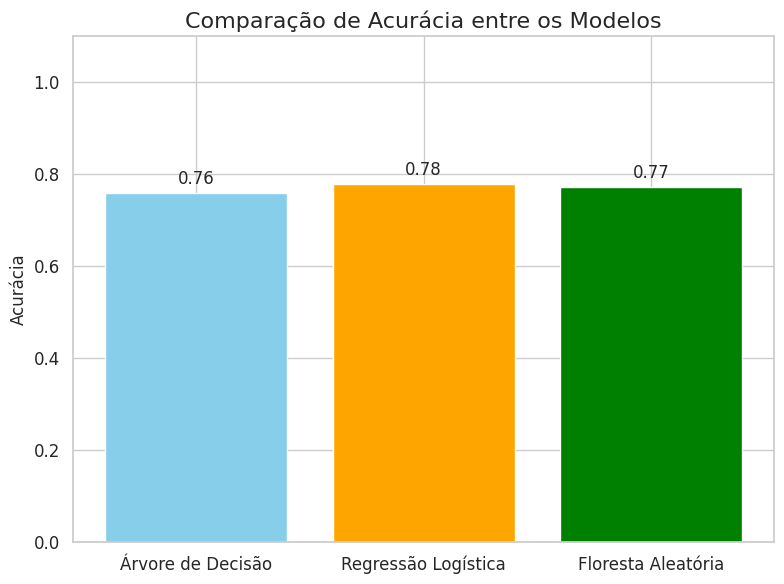

In [62]:
models = ['Árvore de Decisão', 'Regressão Logística', 'Floresta Aleatória']
accuracies = [accuracy_dt, accuracy_lr, accuracy_rf]

plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['skyblue', 'orange', 'green'])

plt.title('Comparação de Acurácia entre os Modelos', fontsize=16)
plt.ylabel('Acurácia', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


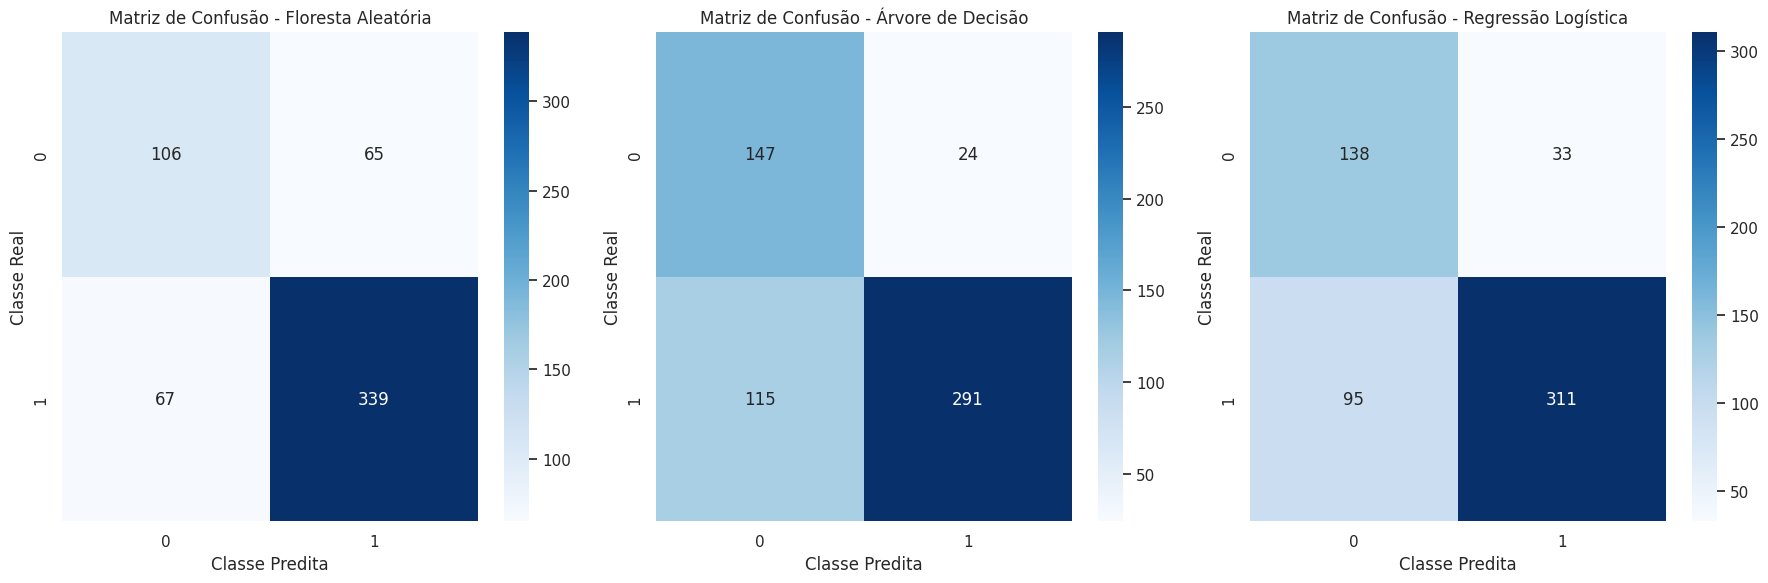

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão - Floresta Aleatória')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matriz de Confusão - Árvore de Decisão')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Matriz de Confusão - Regressão Logística')
axes[2].set_ylabel('Classe Real')
axes[2].set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()
